### $$\underline{\text{DHF : Lab 5}}$$ 

##### $$\text{Arnaud Capitan, Achraf Ouboujemaa, Vasco Nappa}$$ 
___



### Librairies

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

___

### Data Loading and Preprocessing

In [90]:
stock_ids = ["0","1","2"]
days = ["Monday","Tuesday","Wednesday","Thursday","Friday"]
day_ids = ["0","1","2","3","4"]
extensions = ["updates","trades"]

trades = np.zeros((len(stock_ids), len(day_ids)), dtype=pd.DataFrame)
updates = np.zeros((len(stock_ids), len(day_ids)), dtype=pd.DataFrame)

def get_data_path(stock_id, day, extension):
    return f"Data/stock{stock_id}_day{day}_{extension}.csv.gz"

for stock_id in stock_ids :
    for day_id in day_ids :
        data_path_updates = get_data_path(stock_id, day_id, "updates")
        data_path_trades = get_data_path(stock_id, day_id, "trades")
        df_updates = pd.read_csv(data_path_updates)
        df_trades = pd.read_csv(data_path_trades)
        df_updates["ts" ] = pd.to_datetime(df_updates["ts"])
        df_trades["ts"] = pd.to_datetime(df_trades["ts"])
        df_updates = df_updates.sort_values("ts").reset_index(drop=True)
        df_trades = df_trades.sort_values("ts").reset_index(drop=True)
        updates[stock_ids.index(stock_id), day_ids.index(day_id)] = df_updates
        trades[stock_ids.index(stock_id), day_ids.index(day_id)] = df_trades

### I. A propagator model for trades

In this question, we study market impact in trade time. For each stock, we first compute the empirical response function, then calibrate a propagator model for trades, and finally compare the model to the data

A first step is to sign the trades we have, for that we will use the method seen in course 1. Since trade signs are not directly available in the trades files, we first construct sign proxies. We use the tick test from trades only, and the quote test by matching each trade with the latest available quote.

In [91]:
def tick_test(trades_df):
    df = trades_df.sort_values("ts").copy()
    delta = df["price"].diff()

    df["eps_tick"] = np.nan
    df.loc[delta > 0, "eps_tick"] = 1
    df.loc[delta < 0, "eps_tick"] = -1

    nonzero_delta = delta[delta != 0].dropna()
    first_sign = int(np.sign(nonzero_delta.iloc[0])) if len(nonzero_delta) > 0 else 1

    df["eps_tick"] = df["eps_tick"].ffill().fillna(first_sign).astype(int)
    return df

def quote_test(trades_df, updates_df):
    quotes = (
        updates_df[["ts", "bp", "ap"]]
        .dropna()
        .sort_values("ts")
        .copy()
    )

    df = pd.merge_asof(
        trades_df.sort_values("ts").copy(),
        quotes,
        on="ts",
        direction="backward",
        allow_exact_matches=False
    )

    df["eps_quote"] = np.nan
    df.loc[df["price"] == df["ap"], "eps_quote"] = 1
    df.loc[df["price"] == df["bp"], "eps_quote"] = -1

    return df

def infer_trade_signs(trades_df, updates_df):
    df = tick_test(trades_df)
    df = quote_test(df, updates_df)
    df["eps"] = df["eps_quote"].fillna(df["eps_tick"]).astype(int)
    return df

for i, stock_id in enumerate(stock_ids):
    for j, day_id in enumerate(day_ids):
        signed_trades[i, j] = infer_trade_signs(trades[i, j], updates[i, j])
        
signed_trades[0, 0][["ts", "price", "qty", "eps_tick", "eps_quote", "eps"]].head(10)

,ts,price,qty,eps_tick,eps_quote,eps
0,2026-01-26 09:00:27.018202,55.00,2,-1,NaN,-1
1,2026-01-26 09:00:27.018202,55.00,10,-1,NaN,-1
2,2026-01-26 09:00:27.018202,55.00,10,-1,NaN,-1
3,2026-01-26 09:00:27.041728,54.97,446,-1,-1.0,-1
4,2026-01-26 09:00:27.042153,54.97,24,-1,1.0,1
5,2026-01-26 09:00:27.042804,54.97,64,-1,-1.0,-1
6,2026-01-26 09:00:27.058654,54.97,9,-1,-1.0,-1
7,2026-01-26 09:00:27.058922,54.97,7,-1,1.0,1
8,2026-01-26 09:00:27.061584,54.97,125,-1,1.0,1
9,2026-01-26 09:00:27.072145,54.95,125,-1,-1.0,-1


In [92]:
mask = df["eps_quote"].notna()
print((df.loc[mask, "eps_quote"] == df.loc[mask, "eps_tick"]).mean())

0.7018531228551819


The quote test classifies most trades, while the remaining ones are signed with the tick test. This gives a complete proxy for the trade sign needed to compute the response function.

The agreement rate between the tick test and the quote test is around 70% on the trades for which the quote test is available. This is reasonable for proxy trade signs, so we keep the final sign obtained from the quote test when available and from the tick test otherwise.

In [93]:
def prepare_trade_data(signed_trades_df, updates_df):
    quotes = (
        updates_df[["ts", "bp", "ap"]]
        .dropna()
        .sort_values("ts")
        .copy()
    )
    quotes["mid"] = (quotes["bp"] + quotes["ap"]) / 2

    df = pd.merge_asof(
        signed_trades_df.sort_values("ts").copy(),
        quotes[["ts", "mid"]],
        on="ts",
        direction="backward",
        allow_exact_matches=False
    ).dropna(subset=["mid", "eps"]).copy()

    df["eps"] = df["eps"].astype(int)
    return df[["ts", "mid", "eps"]]


def response_function(df, max_lag=200):
    p = df["mid"].to_numpy()
    eps = df["eps"].to_numpy()
    n = len(df)

    max_lag = min(max_lag, n - 1)

    R = np.array([
        np.mean((p[lag:] - p[:-lag]) * eps[:-lag])
        for lag in range(1, max_lag + 1)
    ])

    return pd.Series(R, index=np.arange(1, max_lag + 1))


max_lag = 200

responses_by_day = {}
responses_by_stock = pd.DataFrame(index=np.arange(1, max_lag + 1))

for i, stock_id in enumerate(stock_ids):
    daily_R = pd.DataFrame(index=np.arange(1, max_lag + 1))

    for j, day_id in enumerate(day_ids):
        df_day = prepare_trade_data(signed_trades[i, j], updates[i, j])
        R_day = response_function(df_day, max_lag=max_lag)
        daily_R[days[j]] = R_day

    responses_by_day[stock_id] = daily_R
    responses_by_stock[f"stock{stock_id}"] = daily_R.mean(axis=1)

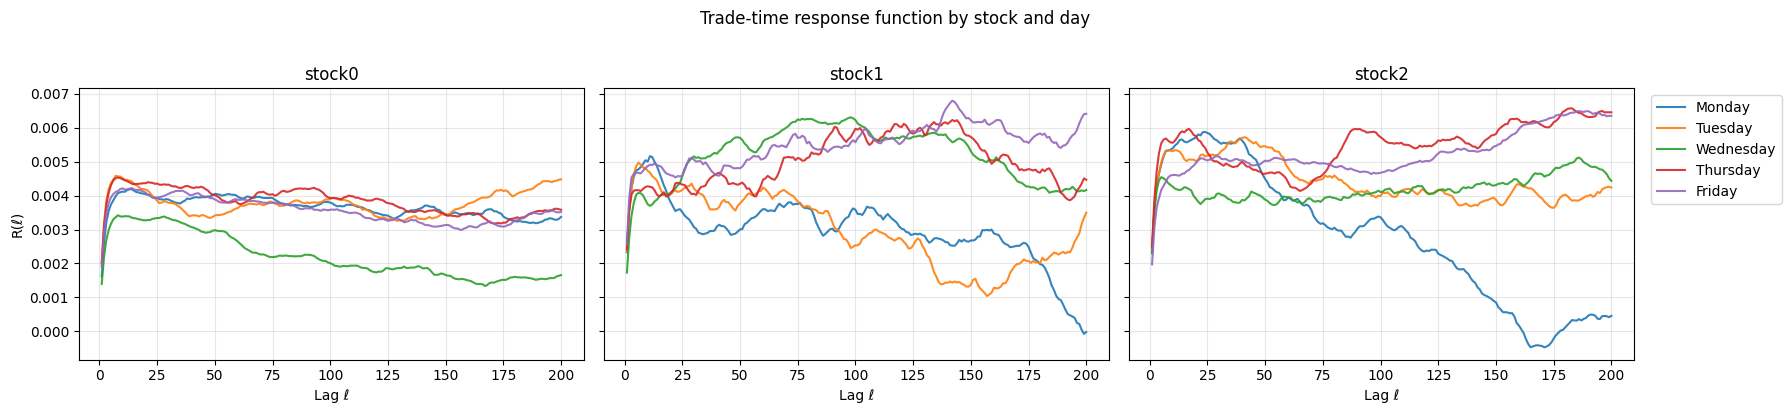

In [94]:
fig, axes = plt.subplots(1, len(stock_ids), figsize=(18, 4), sharey=True)

for i, stock_id in enumerate(stock_ids):
    ax = axes[i]
    daily_R = responses_by_day[stock_id]

    for day in daily_R.columns:
        ax.plot(daily_R.index, daily_R[day], label=day, alpha=0.9)

    ax.set_title(f"stock{stock_id}")
    ax.set_xlabel("Lag ℓ")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("R(ℓ)")
axes[-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.suptitle("Trade-time response function by stock and day", y=1.02)
plt.tight_layout()
plt.show()

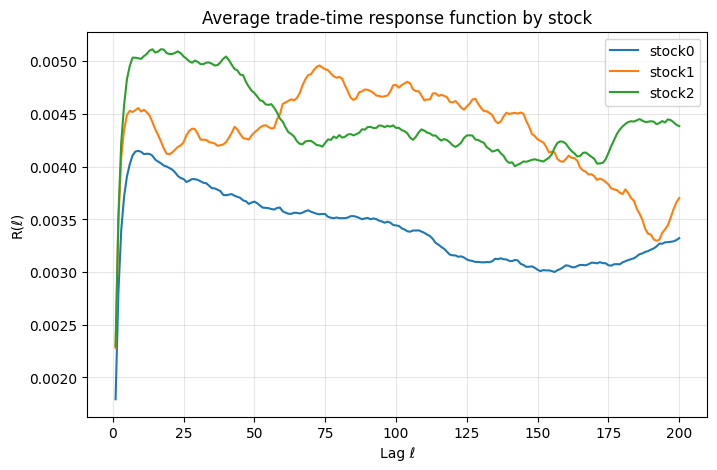

In [95]:
plt.figure(figsize=(8, 5))

for col in responses_by_stock.columns:
    plt.plot(responses_by_stock.index, responses_by_stock[col], label=col)

plt.xlabel("Lag ℓ")
plt.ylabel("R(ℓ)")
plt.title("Average trade-time response function by stock")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

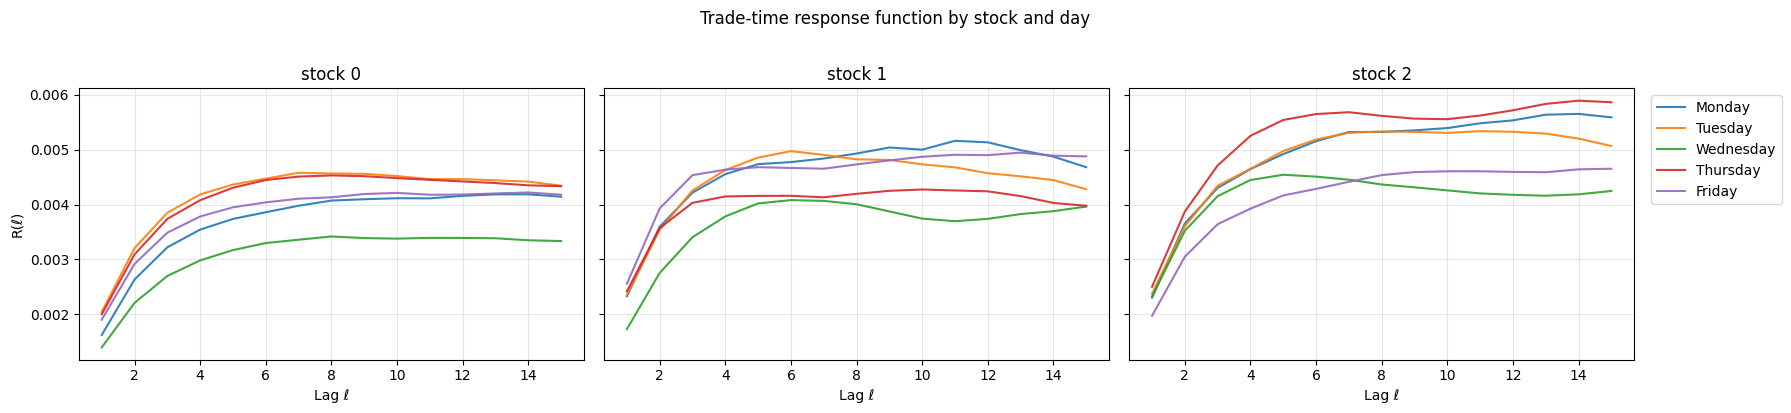

In [96]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(stock_ids), figsize=(18, 4), sharey=True)

for i, stock_id in enumerate(stock_ids):
    ax = axes[i]
    # Keep only the first 15 rows of the dataframe
    daily_R = responses_by_day[stock_id].head(15) 

    for day in daily_R.columns:
        ax.plot(daily_R.index, daily_R[day], label=day, alpha=0.9)

    ax.set_title(f"stock {stock_id}")
    ax.set_xlabel("Lag ℓ")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("R(ℓ)")
axes[-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.suptitle("Trade-time response function by stock and day", y=1.02)
plt.tight_layout()
plt.show()


Looking at the plots, we can clearly see two main market microstructure effects:

* Square Root Law (Initial Concavity): If we treat the lag $\ell$ as a proxy for cumulative volume, the steep, concave curve at the beginning ($\ell < 5$) shows the square root law in action. The first few trades eat up the available liquidity and have the highest marginal impact.

* Transient Impact (The Plateau): Around lag 10 to 15, the curves flatten out and even start to dip slightly. This shows that the market impact is transient—liquidity eventually replenishes and the price stops climbing indefinitely.

#### Question 1.2 — Calibration of the propagator model

We calibrate the trade propagator model from the lagged covariance between returns and trade signs. Following the course, we first estimate the sign autocorrelation and the sign-return covariance, then recover the propagator kernel by truncation and matrix inversion.

In [97]:
def build_stock_series(stock_idx):
    parts = []

    for day_idx in range(len(day_ids)):
        df_day = prepare_trade_data(
            signed_trades[stock_idx, day_idx],
            updates[stock_idx, day_idx]
        )
        parts.append(df_day.reset_index(drop=True))

    return pd.concat(parts, ignore_index=True)


def sign_autocorrelation(eps, max_lag):
    n = len(eps)
    max_lag = min(max_lag, n - 1)

    C = np.empty(max_lag + 1)
    C[0] = np.mean(eps * eps)

    for lag in range(1, max_lag + 1):
        C[lag] = np.mean(eps[lag:] * eps[:-lag])

    return C


def sign_return_covariance(p, eps, max_lag):
    r = np.diff(p)
    n = len(r)
    max_lag = min(max_lag, n - 1)

    Cr_eps = np.empty(max_lag + 1)
    Cr_eps[0] = np.mean(r * eps[:-1])

    for lag in range(1, max_lag + 1):
        Cr_eps[lag] = np.mean(r[lag:] * eps[:-1 - lag])

    return Cr_eps


def calibrate_propagator(p, eps, max_lag):
    max_lag = min(max_lag, len(eps) - 2)

    C = sign_autocorrelation(eps, max_lag)
    Cr_eps = sign_return_covariance(p, eps, max_lag)

    A = np.array([
        [C[abs(m - ell)] for m in range(max_lag + 1)]
        for ell in range(max_lag + 1)
    ])

    h = np.linalg.lstsq(A, Cr_eps, rcond=None)[0]

    g = np.zeros(max_lag + 1)
    g[1:] = np.cumsum(h[:-1])

    return C, Cr_eps, h, g


def model_response_from_g(g, C):
    L = len(g) - 1
    R_model = np.zeros(L)

    for ell in range(1, L + 1):
        term1 = g[ell]

        term2 = sum(
            g[ell - k] * C[k]
            for k in range(1, ell)
        )

        term3 = sum(
            (g[k + ell] - g[k]) * C[k]
            for k in range(1, L - ell + 1)
        )

        R_model[ell - 1] = term1 + term2 + term3

    return R_model


max_lag = 200
results = {}

for i, stock_id in enumerate(stock_ids):
    df_stock = build_stock_series(i)

    p = df_stock["mid"].to_numpy()
    eps = df_stock["eps"].to_numpy()

    usable_lag = min(max_lag, len(df_stock) - 2)

    C, Cr_eps, h, g = calibrate_propagator(p, eps, max_lag=usable_lag)
    R_emp = response_function(df_stock, max_lag=usable_lag).to_numpy()
    R_model = model_response_from_g(g, C)

    results[stock_id] = {
        "df": df_stock,
        "C": C,
        "Cr_eps": Cr_eps,
        "h": h,
        "g": g,
        "R_emp": R_emp,
        "R_model": R_model
    }

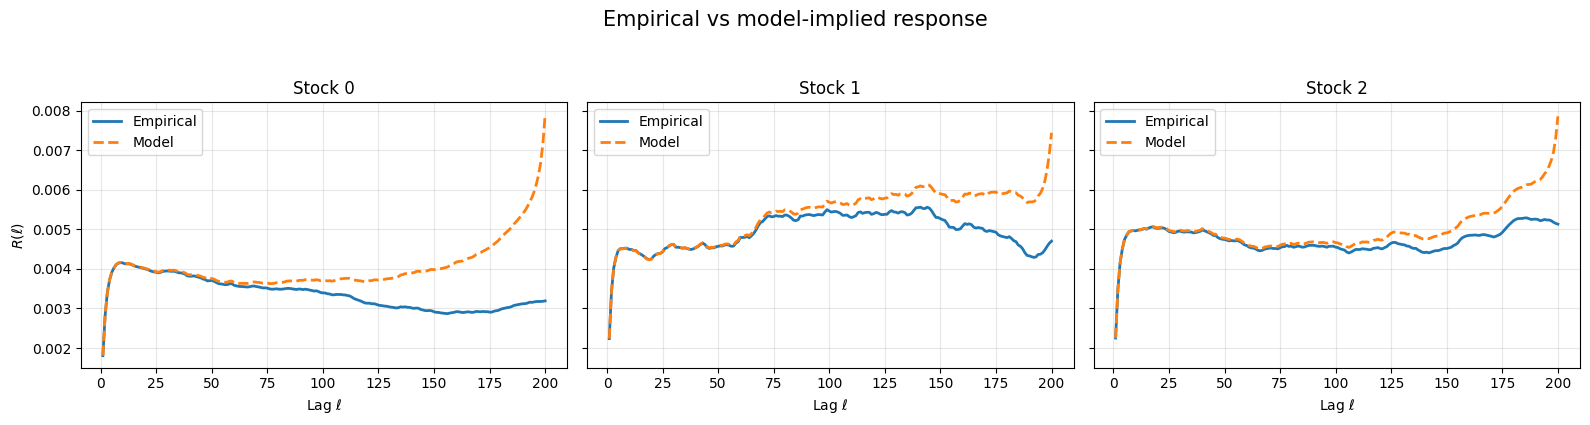

In [98]:
fig, axes = plt.subplots(1, len(stock_ids), figsize=(16, 4), sharey=True)

if len(stock_ids) == 1:
    axes = [axes]

for i, stock_id in enumerate(stock_ids):
    res = results[stock_id]
    lags = np.arange(1, len(res["R_emp"]) + 1)

    axes[i].plot(lags, res["R_emp"], lw=2, label="Empirical")
    axes[i].plot(lags, res["R_model"], lw=2, ls="--", label="Model")
    axes[i].set_title(f"Stock {stock_id}")
    axes[i].set_xlabel("Lag $\\ell$")
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

axes[0].set_ylabel("$R(\\ell)$")
plt.suptitle("Empirical vs model-implied response", fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

The propagator model reproduces the empirical response fairly well at short and intermediate lags for the three stocks. In particular, the model captures the initial increase and the general level of the response function, which suggests that the calibration is able to recover the main impact dynamics.

However, the fit deteriorates at large lags. For all three stocks, the model tends to overestimate the response in the tail, with a strong upward deviation. This likely reflects finite-sample noise and instability in the inversion step used to recover the propagator kernel.

 Overall, the model provides a reasonable description of the response function, but its fit is clearly more reliable at small and medium lags than at the largest lags.

### II. A propagator model for LOB events

We select stock0 and build an event-time series from the best-quote updates. For each event, we infer its side and its sign, then compute and plot the autocorrelation functions.

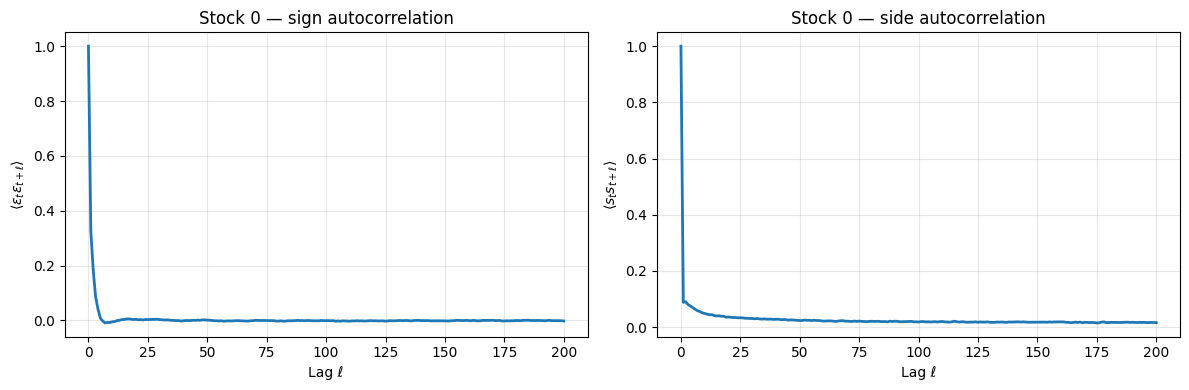

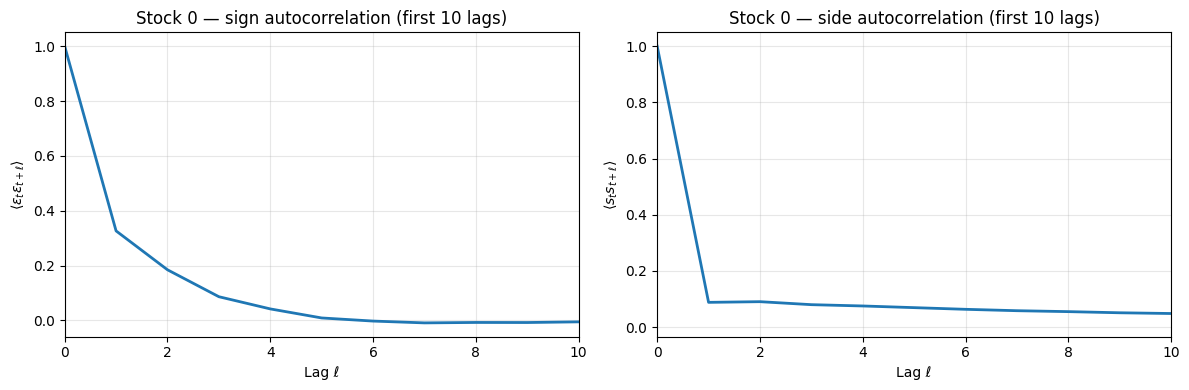

In [99]:
stock_idx = 0
max_lag = 200

def extract_lob_events(updates_df):
    df = (
        updates_df[["ts", "bp", "bq", "ap", "aq"]]
        .dropna()
        .sort_values("ts")
        .reset_index(drop=True)
        .copy()
    )

    prev = df.shift(1)

    bid_changed = (df["bp"] != prev["bp"]) | (df["bq"] != prev["bq"])
    ask_changed = (df["ap"] != prev["ap"]) | (df["aq"] != prev["aq"])

    bid_events = df.loc[bid_changed].copy()
    bid_prev = prev.loc[bid_changed].copy()
    bid_events["s"] = 1
    bid_events["eps"] = np.where(
        (bid_events["bp"].to_numpy() > bid_prev["bp"].to_numpy()) |
        (
            (bid_events["bp"].to_numpy() == bid_prev["bp"].to_numpy()) &
            (bid_events["bq"].to_numpy() > bid_prev["bq"].to_numpy())
        ),
        1,
        -1
    )

    ask_events = df.loc[ask_changed].copy()
    ask_prev = prev.loc[ask_changed].copy()
    ask_events["s"] = -1
    ask_events["eps"] = np.where(
        (ask_events["ap"].to_numpy() < ask_prev["ap"].to_numpy()) |
        (
            (ask_events["ap"].to_numpy() == ask_prev["ap"].to_numpy()) &
            (ask_events["aq"].to_numpy() > ask_prev["aq"].to_numpy())
        ),
        -1,
        1
    )

    events = pd.concat([bid_events, ask_events], ignore_index=True)
    events = events.sort_values("ts").reset_index(drop=True)

    return events[["ts", "bp", "bq", "ap", "aq", "s", "eps"]]


def pm1_autocorrelation(x, max_lag):
    x = np.asarray(x, dtype=float)
    L = min(max_lag, len(x) - 1)

    out = np.full(max_lag + 1, np.nan)
    out[0] = np.mean(x * x)

    for lag in range(1, L + 1):
        out[lag] = np.mean(x[:-lag] * x[lag:])

    return out


eps_acf_days = []
side_acf_days = []
events_by_day = {}

for day_idx, day_name in enumerate(days):
    events_day = extract_lob_events(updates[stock_idx, day_idx])
    events_by_day[day_name] = events_day

    eps_acf_days.append(pm1_autocorrelation(events_day["eps"], max_lag))
    side_acf_days.append(pm1_autocorrelation(events_day["s"], max_lag))

eps_acf = np.nanmean(np.vstack(eps_acf_days), axis=0)
side_acf = np.nanmean(np.vstack(side_acf_days), axis=0)

lags = np.arange(max_lag + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(lags, eps_acf, lw=2)
axes[0].set_title(f"Stock {stock_idx} — sign autocorrelation")
axes[0].set_xlabel("Lag ℓ")
axes[0].set_ylabel(r"$\langle \varepsilon_t \varepsilon_{t+\ell} \rangle$")
axes[0].grid(True, alpha=0.3)

axes[1].plot(lags, side_acf, lw=2)
axes[1].set_title(f"Stock {stock_idx} — side autocorrelation")
axes[1].set_xlabel("Lag ℓ")
axes[1].set_ylabel(r"$\langle s_t s_{t+\ell} \rangle$")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(lags, eps_acf, lw=2)
axes[0].set_xlim(0, 10)
axes[0].set_title(f"Stock {stock_idx} — sign autocorrelation (first 10 lags)")
axes[0].set_xlabel("Lag ℓ")
axes[0].set_ylabel(r"$\langle \varepsilon_t \varepsilon_{t+\ell} \rangle$")
axes[0].grid(True, alpha=0.3)

axes[1].plot(lags, side_acf, lw=2)
axes[1].set_xlim(0, 10)
axes[1].set_title(f"Stock {stock_idx} — side autocorrelation (first 10 lags)")
axes[1].set_xlabel("Lag ℓ")
axes[1].set_ylabel(r"$\langle s_t s_{t+\ell} \rangle$")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The sign autocorrelation is strongly positive at very short lags and then decays quickly toward zero. 

The side autocorrelation is also positive, but more persistent, which suggests that events tend to remain on the same side of the book for several consecutive updates.

#### Empirical response function 

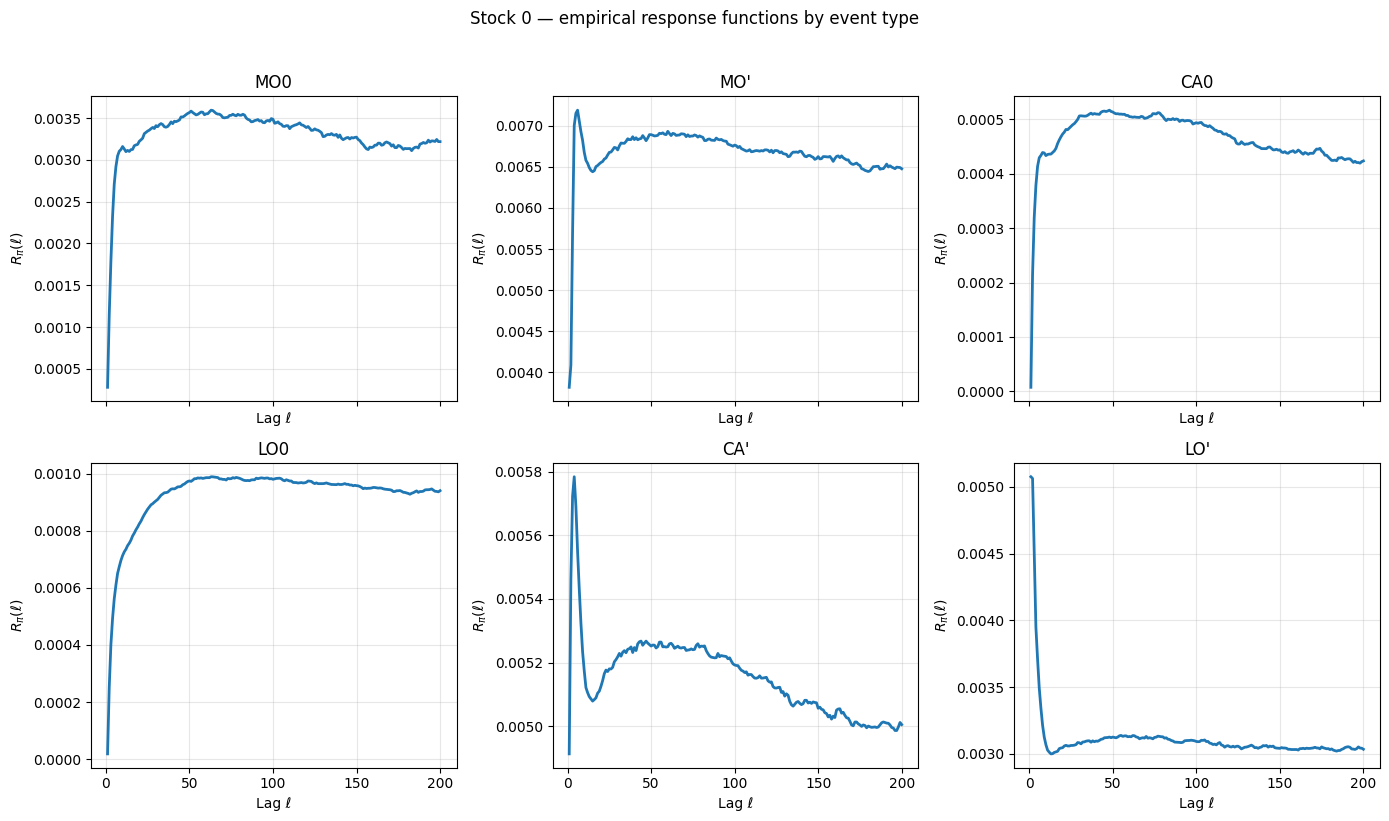

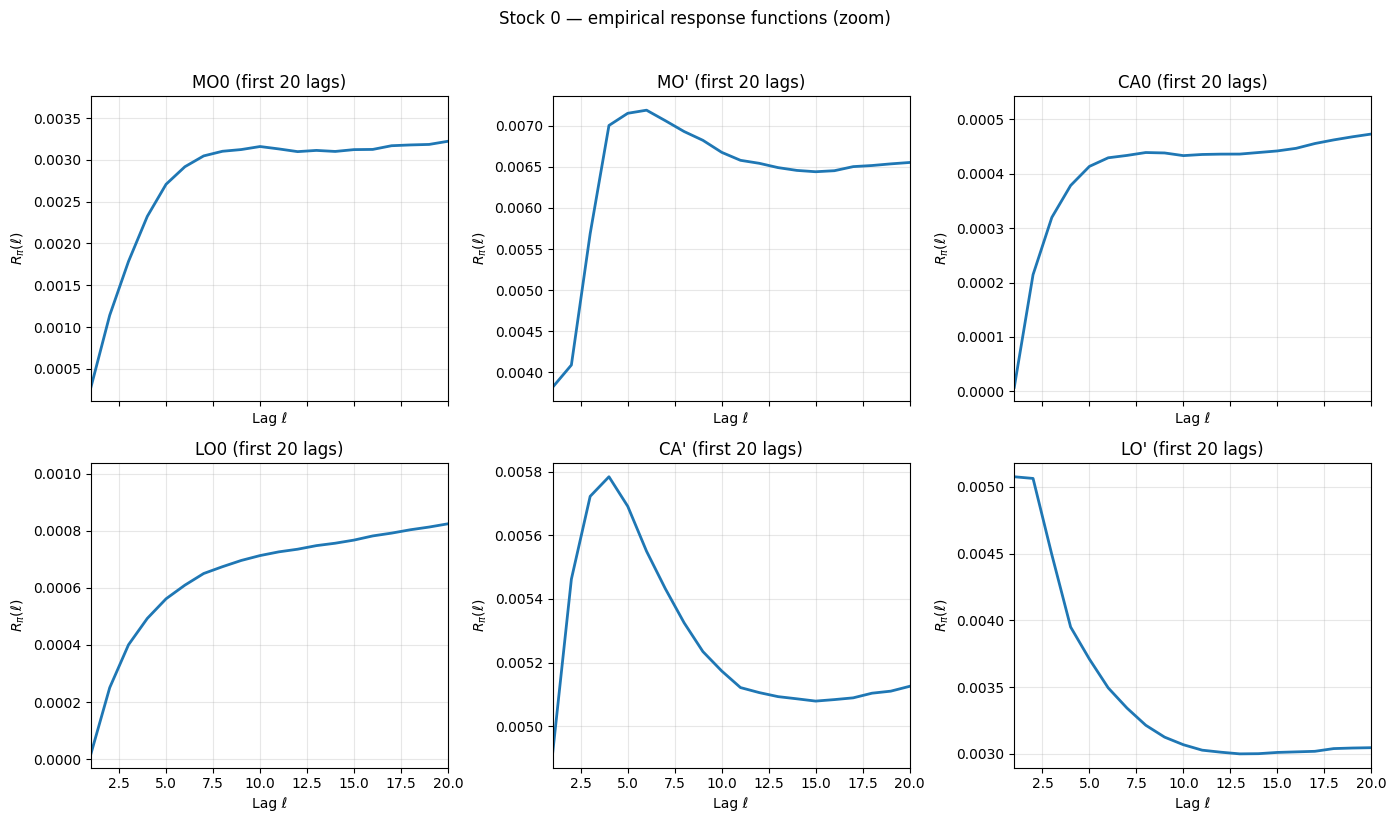

In [100]:
stock_idx = 0
max_lag = 200
event_types = ["MO0", "MO'", "CA0", "LO0", "CA'", "LO'"]

def build_typed_events_fast(updates_df, signed_trades_df):
    u = (
        updates_df[["ts", "bp", "bq", "ap", "aq"]]
        .dropna()
        .sort_values("ts")
        .reset_index(drop=True)
        .copy()
    )

    tr = (
        signed_trades_df[["ts", "eps"]]
        .dropna()
        .sort_values("ts")
        .reset_index(drop=True)
        .copy()
    )

    ut = u["ts"].to_numpy(dtype="datetime64[ns]")
    bt = tr.loc[tr["eps"] == 1, "ts"].to_numpy(dtype="datetime64[ns]")
    st = tr.loc[tr["eps"] == -1, "ts"].to_numpy(dtype="datetime64[ns]")

    buy_cum = np.searchsorted(bt, ut, side="right")
    sell_cum = np.searchsorted(st, ut, side="right")

    buy_between = (buy_cum[1:] - buy_cum[:-1]) > 0
    sell_between = (sell_cum[1:] - sell_cum[:-1]) > 0

    prev = u.iloc[:-1].reset_index(drop=True)
    curr = u.iloc[1:].reset_index(drop=True)

    mid_prev = 0.5 * (prev["bp"].to_numpy() + prev["ap"].to_numpy())

    bp0 = prev["bp"].to_numpy()
    bq0 = prev["bq"].to_numpy()
    ap0 = prev["ap"].to_numpy()
    aq0 = prev["aq"].to_numpy()

    bp1 = curr["bp"].to_numpy()
    bq1 = curr["bq"].to_numpy()
    ap1 = curr["ap"].to_numpy()
    aq1 = curr["aq"].to_numpy()

    ts1 = curr["ts"].to_numpy()

    bid_changed = (bp1 != bp0) | (bq1 != bq0)
    ask_changed = (ap1 != ap0) | (aq1 != aq0)

    bid_pi = np.full(len(curr), "", dtype=object)
    bid_eps = np.full(len(curr), np.nan)

    m = bid_changed & (bp1 > bp0)
    bid_pi[m] = "LO'"
    bid_eps[m] = 1

    m = bid_changed & (bp1 == bp0) & (bq1 > bq0)
    bid_pi[m] = "LO0"
    bid_eps[m] = 1

    m = bid_changed & (bp1 < bp0)
    bid_pi[m] = np.where(sell_between[m], "MO'", "CA'")
    bid_eps[m] = -1

    m = bid_changed & (bp1 == bp0) & (bq1 < bq0)
    bid_pi[m] = np.where(sell_between[m], "MO0", "CA0")
    bid_eps[m] = -1

    ask_pi = np.full(len(curr), "", dtype=object)
    ask_eps = np.full(len(curr), np.nan)

    m = ask_changed & (ap1 < ap0)
    ask_pi[m] = "LO'"
    ask_eps[m] = -1

    m = ask_changed & (ap1 == ap0) & (aq1 > aq0)
    ask_pi[m] = "LO0"
    ask_eps[m] = -1

    m = ask_changed & (ap1 > ap0)
    ask_pi[m] = np.where(buy_between[m], "MO'", "CA'")
    ask_eps[m] = 1

    m = ask_changed & (ap1 == ap0) & (aq1 < aq0)
    ask_pi[m] = np.where(buy_between[m], "MO0", "CA0")
    ask_eps[m] = 1

    bid_events = pd.DataFrame({
        "ts": ts1[bid_changed],
        "pi": bid_pi[bid_changed],
        "eps": bid_eps[bid_changed].astype(int),
        "mid": mid_prev[bid_changed]
    })

    ask_events = pd.DataFrame({
        "ts": ts1[ask_changed],
        "pi": ask_pi[ask_changed],
        "eps": ask_eps[ask_changed].astype(int),
        "mid": mid_prev[ask_changed]
    })

    events = (
        pd.concat([bid_events, ask_events], ignore_index=True)
        .sort_values("ts")
        .reset_index(drop=True)
    )

    return events


def response_by_event_type(events_df, max_lag, event_types):
    p = events_df["mid"].to_numpy()
    eps = events_df["eps"].to_numpy()
    pi = events_df["pi"].to_numpy()

    L = min(max_lag, len(events_df) - 1)
    out = {event: np.full(L, np.nan) for event in event_types}

    for event in event_types:
        mask_full = (pi == event)

        for lag in range(1, L + 1):
            mask = mask_full[:-lag]
            if mask.any():
                dp = p[lag:] - p[:-lag]
                out[event][lag - 1] = np.mean(dp[mask] * eps[:-lag][mask])

    return out


responses_days = {event: [] for event in event_types}

for day_idx in range(len(day_ids)):
    events_day = build_typed_events_fast(
        updates[stock_idx, day_idx],
        signed_trades[stock_idx, day_idx]
    )

    resp_day = response_by_event_type(events_day, max_lag=max_lag, event_types=event_types)

    for event in event_types:
        responses_days[event].append(resp_day[event])

R_pi = {
    event: np.nanmean(np.vstack(responses_days[event]), axis=0)
    for event in event_types
}

lags = np.arange(1, len(next(iter(R_pi.values()))) + 1)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)
axes = axes.ravel()

for ax, event in zip(axes, event_types):
    ax.plot(lags, R_pi[event], lw=2)
    ax.set_title(event)
    ax.set_xlabel("Lag ℓ")
    ax.set_ylabel(r"$R_\pi(\ell)$")
    ax.grid(True, alpha=0.3)

plt.suptitle("Stock 0 — empirical response functions by event type", y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)
axes = axes.ravel()

for ax, event in zip(axes, event_types):
    ax.plot(lags, R_pi[event], lw=2)
    ax.set_xlim(1, 20)
    ax.set_title(f"{event} (first 20 lags)")
    ax.set_xlabel("Lag ℓ")
    ax.set_ylabel(r"$R_\pi(\ell)$")
    ax.grid(True, alpha=0.3)

plt.suptitle("Stock 0 — empirical response functions (zoom)", y=1.02)
plt.tight_layout()
plt.show()

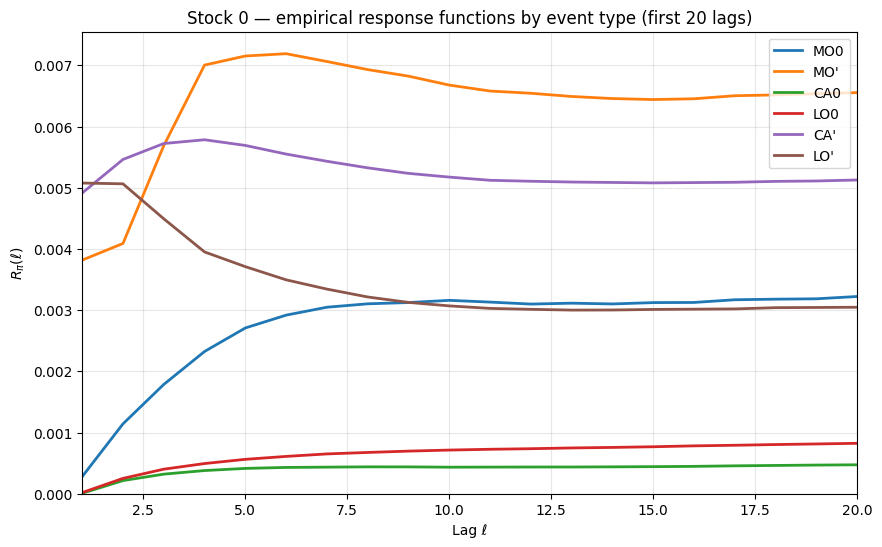

In [101]:
lags = np.arange(1, len(R_pi[event_types[0]]) + 1)

plt.figure(figsize=(10, 6))

for event in event_types:
    plt.plot(lags, R_pi[event], lw=2, label=event)

plt.xlim(1, 20)
plt.ylim(bottom=0)
plt.xlabel("Lag ℓ")
plt.ylabel(r"$R_\pi(\ell)$")
plt.title("Stock 0 — empirical response functions by event type (first 20 lags)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

The empirical responses are all positive, which means that each event type is followed on average by a price move in the direction of its sign. As expected, the largest responses are obtained for the most aggressive events, while passive events have a much smaller impact.

- **MO'**: strongest and most immediate impact, since these market orders consume all liquidity at the best quote and move the price.
- **MO0**: large positive response as well, but smaller than **MO'**, because these orders consume liquidity without immediately changing the best price.
- **CA'**: strong short-run impact, since cancellations that remove the best quote also move the price.
- **CA0**: much weaker effect, because the cancellation does not change the best price.
- **LO'**: large instantaneous effect, as an aggressive limit order improves the quote and moves the price.
- **LO0**: positive but moderate response, since the order adds liquidity at the current best quote without changing the price.

Overall, the results are consistent with the idea that price-changing events (**MO'**, **CA'**, **LO'**) have the strongest impact, while non-price-changing events (**MO0**, **CA0**, **LO0**) have a smaller effect.

,MO0,MO',CA0,LO0,CA',LO'
MO0,1.979,0.546,0.437,-0.074,2.296,1.061
MO',0.050,1.171,0.188,0.405,2.012,-1.294
CA0,0.676,0.318,0.450,0.169,0.440,0.290
LO0,-0.519,0.199,0.194,0.388,0.564,0.260
CA',2.805,1.572,0.399,0.545,-0.119,1.105
LO',0.062,-4.421,0.782,0.568,-1.407,-0.211


,MO0,MO',CA0,LO0,CA',LO'
MO0,0.701,0.345,0.016,-0.027,-0.111,-0.054
MO',-0.060,-0.288,-0.048,0.017,-0.150,-0.104
CA0,0.037,0.032,0.035,-0.052,-0.015,0.020
LO0,0.014,0.096,-0.081,0.077,-0.005,0.036
CA',0.039,0.065,-0.059,0.008,0.050,-0.209
LO',-0.168,-0.306,-0.017,-0.020,-0.254,0.126


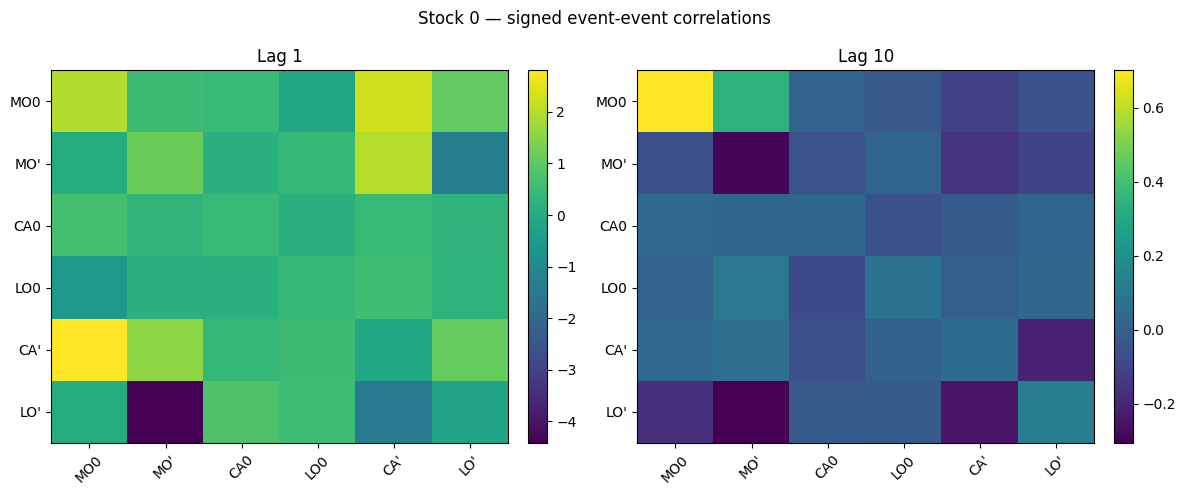

In [102]:
stock_idx = 0
max_lag = 200
event_types = ["MO0", "MO'", "CA0", "LO0", "CA'", "LO'"]

def signed_event_event_correlations_fast(events_df, max_lag, event_types):
    pi = events_df["pi"].to_numpy()
    eps = events_df["eps"].to_numpy().astype(float)

    X = np.column_stack([
        (pi == event).astype(float) * eps
        for event in event_types
    ])

    probs = np.array([(pi == event).mean() for event in event_types], dtype=float)
    denom = np.outer(probs, probs)

    L = min(max_lag, len(events_df) - 1)
    out = np.full((L + 1, len(event_types), len(event_types)), np.nan)

    for lag in range(L + 1):
        if lag == 0:
            A = X
            B = X
        else:
            A = X[:-lag]
            B = X[lag:]

        num = (A.T @ B) / len(A)

        with np.errstate(divide="ignore", invalid="ignore"):
            out[lag] = num / denom

    return out


corr_days = []

for day_idx in range(len(day_ids)):
    events_day = build_typed_events_fast(
        updates[stock_idx, day_idx],
        signed_trades[stock_idx, day_idx]
    )
    corr_days.append(
        signed_event_event_correlations_fast(
            events_day,
            max_lag=max_lag,
            event_types=event_types
        )
    )

min_L = min(c.shape[0] for c in corr_days)
corr_days = [c[:min_L] for c in corr_days]

C_pi_array = np.nanmean(np.stack(corr_days, axis=0), axis=0)
lags = np.arange(min_L)

C_pi = {
    (pi1, pi2): C_pi_array[:, i, j]
    for i, pi1 in enumerate(event_types)
    for j, pi2 in enumerate(event_types)
}

lag1 = pd.DataFrame(
    C_pi_array[1],
    index=event_types,
    columns=event_types
)

lag10 = pd.DataFrame(
    C_pi_array[10],
    index=event_types,
    columns=event_types
)

display(lag1.round(3))
display(lag10.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(C_pi_array[1], aspect="auto")
axes[0].set_title("Lag 1")
axes[0].set_xticks(range(len(event_types)))
axes[0].set_xticklabels(event_types, rotation=45)
axes[0].set_yticks(range(len(event_types)))
axes[0].set_yticklabels(event_types)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(C_pi_array[10], aspect="auto")
axes[1].set_title("Lag 10")
axes[1].set_xticks(range(len(event_types)))
axes[1].set_xticklabels(event_types, rotation=45)
axes[1].set_yticks(range(len(event_types)))
axes[1].set_yticklabels(event_types)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.suptitle("Stock 0 — signed event-event correlations")
plt.tight_layout()
plt.show()

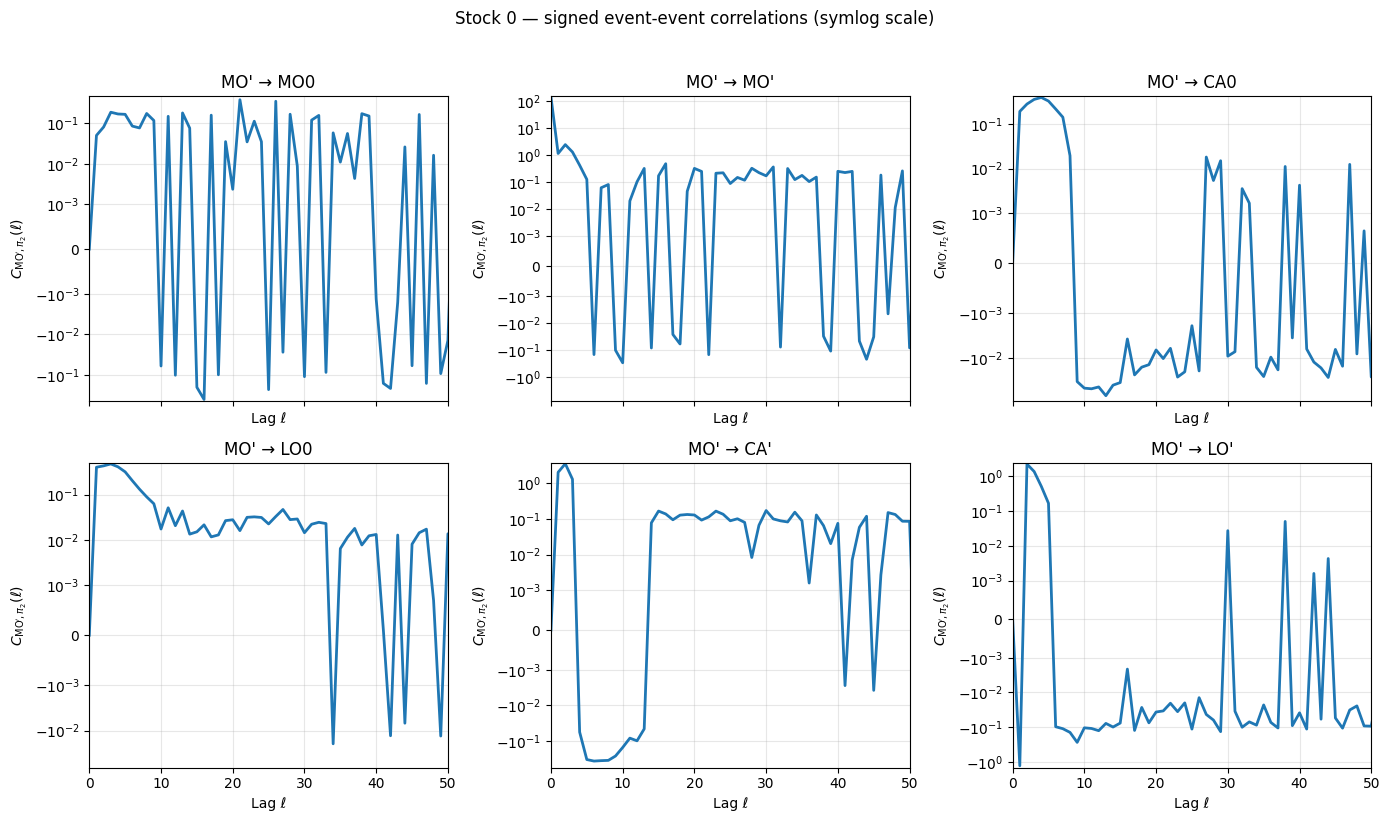

In [103]:
pi1 = "MO'"
event_types = ["MO0", "MO'", "CA0", "LO0", "CA'", "LO'"]

lags = np.arange(len(C_pi[(pi1, event_types[0])]))

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)
axes = axes.ravel()

for ax, pi2 in zip(axes, event_types):
    y = C_pi[(pi1, pi2)]

    ax.plot(lags, y, lw=2)
    ax.set_xlim(0, 50)

    # symlog scale (key part of the lab)
    ax.set_yscale("symlog", linthresh=1e-3)

    ax.set_title(f"{pi1} → {pi2}")
    ax.set_xlabel("Lag ℓ")
    ax.set_ylabel(r"$C_{\mathrm{MO}',\pi_2}(\ell)$")
    ax.grid(True, which="both", alpha=0.3)

plt.suptitle("Stock 0 — signed event-event correlations (symlog scale)", y=1.02)
plt.tight_layout()
plt.show()

We plot $C_{\mathrm{MO}',\pi_2}(\ell)$ for each event type $\pi_2$ using a signed logarithmic scale (`symlog`). This allows us to visualize both small fluctuations around zero and larger correlations at short lags.

#### Question 2.5 — Theoretical responses in the constant impact model

In this part, we compare the empirical response functions $R_\pi(\ell)$ to the theoretical responses predicted by the constant impact model for LOB events.

The idea of the model is to approximate the price change generated by each event type $\pi$ with a constant average impact $\Delta_\pi^R$. Under this approximation, the price movement after an event can be reconstructed by summing the signed impacts of future events. The theoretical response for a given event type therefore depends on three ingredients:

- the average impact of each event type, $\Delta_\pi^R$,
- the empirical frequency of each event type, $P(\pi)$,
- the signed event-event correlations $C_{\pi_1,\pi_2}(\ell)$.

In practice, we estimate these quantities from the data and use them to reconstruct the theoretical response curve for each of the six event types. We then compare these theoretical curves to the empirical responses computed previously in order to assess how well the constant impact model explains the observed market impact dynamics.

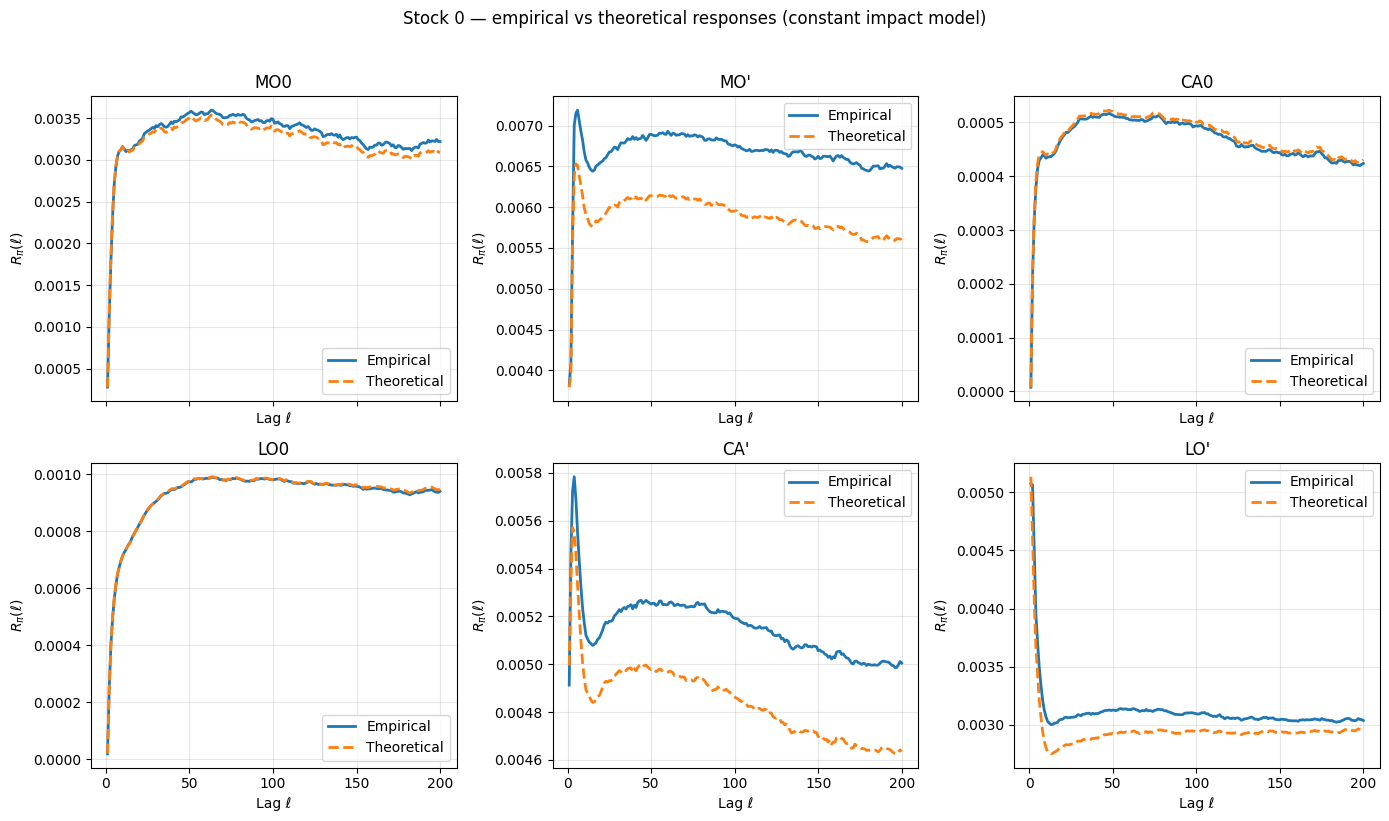

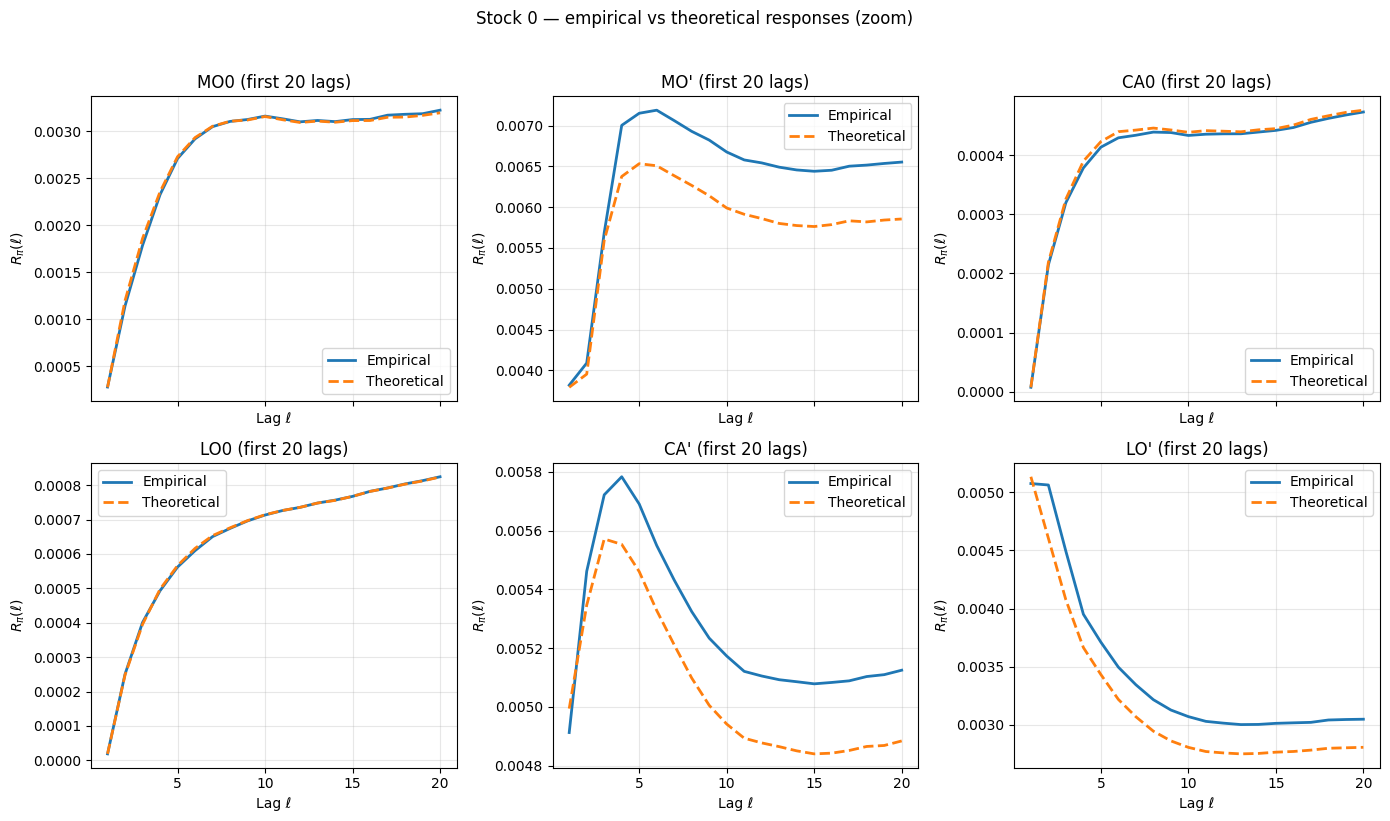

In [104]:
stock_idx = 0
max_lag = min(len(C_pi[("MO0", "MO0")]) - 1, len(R_pi["MO0"]))

event_types = ["MO0", "MO'", "CA0", "LO0", "CA'", "LO'"]

events_days = []
for day_idx in range(len(day_ids)):
    events_day = build_typed_events_fast(
        updates[stock_idx, day_idx],
        signed_trades[stock_idx, day_idx]
    )
    events_days.append(events_day)

events_all = pd.concat(events_days, ignore_index=True)

P_pi = {
    event: (events_all["pi"] == event).mean()
    for event in event_types
}

delta_R = {
    event: R_pi[event][0]
    for event in event_types
}

R_theo = {}

for pi in event_types:
    theo = np.zeros(max_lag)

    for ell in range(1, max_lag + 1):
        val = 0.0
        for n in range(ell):
            for pi1 in event_types:
                val += delta_R[pi1] * P_pi[pi1] * C_pi[(pi, pi1)][n]
        theo[ell - 1] = val

    R_theo[pi] = theo

lags = np.arange(1, max_lag + 1)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)
axes = axes.ravel()

for ax, event in zip(axes, event_types):
    ax.plot(lags, R_pi[event][:max_lag], lw=2, label="Empirical")
    ax.plot(lags, R_theo[event], lw=2, ls="--", label="Theoretical")
    ax.set_title(event)
    ax.set_xlabel("Lag ℓ")
    ax.set_ylabel(r"$R_\pi(\ell)$")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle("Stock 0 — empirical vs theoretical responses (constant impact model)", y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)
axes = axes.ravel()

for ax, event in zip(axes, event_types):
    ax.plot(lags[:20], R_pi[event][:20], lw=2, label="Empirical")
    ax.plot(lags[:20], R_theo[event][:20], lw=2, ls="--", label="Theoretical")
    ax.set_title(f"{event} (first 20 lags)")
    ax.set_xlabel("Lag ℓ")
    ax.set_ylabel(r"$R_\pi(\ell)$")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle("Stock 0 — empirical vs theoretical responses (zoom)", y=1.02)
plt.tight_layout()
plt.show()

Overall, the constant impact model reproduces the empirical responses reasonably well for several event types, especially **MO0**, **CA0**, and **LO0**, for which the theoretical and empirical curves are very close over most lags. This suggests that for these events, a large part of the observed response can be explained by average event impacts combined with the correlation structure of order flow.

For **MO'**, **CA'**, and **LO'**, the fit is weaker. The model captures the broad shape of the response, but it tends to underestimate the empirical level, especially at short and medium horizons. This suggests that for price-changing events, the constant impact approximation is too restrictive, and that their effect may depend more strongly on the local state of the order book.

Overall, the model provides a good first-order description of the response functions, but it is clearly more accurate for non-price-changing events than for the most aggressive price-moving events.